In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
from sklearn.linear_model import LinearRegression
from collections import Counter
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt


Bad key text.latex.preview in file /Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 418 ('savefig.jpeg_quality: 95       # when a jpeg is s

In [2]:
neuron_age_data = sc.read_h5ad("single_cell_age.h5ad")

In [3]:
neuron_age_data

AnnData object with n_obs × n_vars = 21458 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'nCount_LMO', 'nFeature_LMO', 'LMO_maxID', 'LMO_secondID', 'LMO_margin', 'LMO_classification', 'LMO_classification.global', 'hash.ID', 'nCount_SCT', 'nFeature_SCT', 'Celltype', 'Celltype.LowRes', 'Age', 'S.Score', 'G2M.Score', 'Phase', 'SCT_snn_res.0.5', 'SCT_snn_res.0.2', 'SCT_snn_res.0.1', 'SCT_snn_res.0.15', 'SCT_snn_res.0.18', 'SCT_snn_res.0.19', 'SCT_snn_res.0.17', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'Prolif_Lineage_Fraction_of_SVZ'
    var: 'sct.detection_rate', 'sct.gmean', 'sct.variance', 'sct.residual_mean', 'sct.residual_variance', 'sct.variable'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'X_umap_har'
    varm: 'HARMONY', 'PCs'

In [4]:
celltypes = pd.DataFrame(neuron_age_data.obs["Celltype.LowRes"])

In [5]:
Counter(neuron_age_data.obs["Celltype.LowRes"])

Counter({1: 5943,
         5: 939,
         0: 3844,
         8: 268,
         3: 2756,
         4: 2396,
         6: 434,
         10: 107,
         2: 4341,
         7: 274,
         9: 156})

In [7]:
celltype_dict.keys()

dict_keys([1, 5, 0, 8, 3, 4, 6, 10, 2, 7, 9])

In [6]:
celltype_dict = {}
for celltype in Counter(neuron_age_data.obs["Celltype.LowRes"]):
    celltype_dict[celltype] = list(neuron_age_data.obs[neuron_age_data.obs["Celltype.LowRes"] == celltype].index)

In [19]:
neuron_age_data.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,seurat_clusters,nCount_LMO,nFeature_LMO,LMO_maxID,LMO_secondID,LMO_margin,...,SCT_snn_res.0.5,SCT_snn_res.0.2,SCT_snn_res.0.1,SCT_snn_res.0.15,SCT_snn_res.0.18,SCT_snn_res.0.19,SCT_snn_res.0.17,SCT_snn_res.0.3,SCT_snn_res.0.4,Prolif_Lineage_Fraction_of_SVZ
AAACCCAAGAGTCTTC_1,Batch-1,2365.0,1221,3.171247,1,1219.0,4,Sample4-ACCAATGC,Sample1-TGTGATGG,0.578025,...,1,0,0,0,0,0,0,1,1,0.058700
AAACCCAAGGACTTCT_1,Batch-1,2022.0,1135,2.670623,8,1440.0,4,Sample4-ACCAATGC,Sample1-TGTGATGG,0.604401,...,10,7,6,6,7,7,7,8,8,0.058700
AAACCCAGTCACCACG_1,Batch-1,4096.0,1645,1.489258,0,1909.0,4,Sample4-ACCAATGC,Sample1-TGTGATGG,0.898188,...,0,1,2,2,1,1,1,0,0,0.058700
AAACCCAGTCACTCTC_1,Batch-1,3429.0,1555,5.074366,1,1478.0,4,Sample1-TGTGATGG,Sample4-ACCAATGC,0.465037,...,1,0,0,0,0,0,0,1,1,0.208150
AAACCCAGTTCCTTGC_1,Batch-1,3664.0,1580,2.429039,12,1700.0,4,Sample1-TGTGATGG,Sample3-CTCTAGAC,0.828595,...,16,10,9,9,10,10,10,12,13,0.208150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGAGGTCTTTCAT-1_4,Batch-4,6870.0,2258,2.299854,0,532.0,8,BC21-23.9-GAGAGACT,BC22-24.9-CGATTAGC,0.333547,...,0,1,2,2,1,1,1,0,0,0.084746
TTTGGAGGTTTGGAAA-1_4,Batch-4,22517.0,4935,3.428521,4,599.0,8,BC24-25.93-TGTACCAG,BC23-25.93-ATCTACGG,0.485408,...,2,5,4,4,5,5,5,4,5,0.142077
TTTGGTTCAGTGGCTC-1_4,Batch-4,4698.0,2190,2.745849,3,802.0,8,BC18-14.77-TTCCACGT,BC17-3.60-ACTCGAAG,1.105339,...,9,3,3,3,3,3,3,3,2,0.189448
TTTGGTTTCTTTACAC-1_4,Batch-4,4805.0,1891,7.908429,6,651.0,8,BC24-25.93-TGTACCAG,BC22-24.9-CGATTAGC,0.742771,...,5,6,5,5,6,6,6,6,6,0.142077


In [22]:
%pwd

'/Users/charlotte/Desktop/Pellegrini_Lab/Aging'

In [23]:
celltype_names = pd.read_csv("./cell_byCelltypes.csv", header=0, index_col = 0).T
celltype_names

,AAACCCAAGAGTCTTC_1,AAACCCAAGGACTTCT_1,AAACCCAGTCACCACG_1,AAACCCAGTCACTCTC_1,AAACCCAGTTCCTTGC_1,AAACCCATCACTGAAC_1,AAACCCATCCTGCTAC_1,AAACCCATCGTTGTTT_1,AAACCCATCTTAGCAG_1,AAACGAAAGTTACGTC_1,...,TTTGGAGCAATTGCTG-1_4,TTTGGAGCAGCTACTA-1_4,TTTGGAGCATCAACCA-1_4,TTTGGAGCATTGCAAC-1_4,TTTGGAGGTAGAGGAA-1_4,TTTGGAGGTCTTTCAT-1_4,TTTGGAGGTTTGGAAA-1_4,TTTGGTTCAGTGGCTC-1_4,TTTGGTTTCTTTACAC-1_4,TTTGTTGGTCGTCATA-1_4
V1,Oligodendro,Endothelial,Microglia,Oligodendro,Macrophage,Microglia,Oligodendro,Astrocyte_qNSC,Oligodendro,aNSC_NPC,...,Astrocyte_qNSC,Microglia,Microglia,Mural,Oligodendro,Microglia,aNSC_NPC,Astrocyte_qNSC,Oligodendro,aNSC_NPC


In [24]:
celltype_names[celltype_dict[0]]

,AAACCCAGTCACCACG_1,AAACCCATCACTGAAC_1,AAACGCTGTAGGCTCC_1,AAAGGATCATTGGCAT_1,AAAGGGCAGCCGAACA_1,AACAAAGCAGCGTTGC_1,AACAAAGGTGTAAATG_1,AACAACCTCATTTGTC_1,AACAAGATCTCTGCTG_1,AACACACGTAAGACCG_1,...,TTTCACAAGAGCATAT-1_4,TTTCAGTTCTTAGGAC-1_4,TTTCATGCAGACCTGC-1_4,TTTCCTCAGGGACACT-1_4,TTTCGATCAGCACCCA-1_4,TTTGACTAGTGCGCTC-1_4,TTTGACTTCTGGTGGC-1_4,TTTGGAGCAGCTACTA-1_4,TTTGGAGCATCAACCA-1_4,TTTGGAGGTCTTTCAT-1_4
V1,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,...,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia,Microglia


In [25]:
pd.DataFrame(np.unique(celltype_names).reshape(-1, len(np.unique(celltype_names))), columns = [x + 1 for x in range(len(np.unique(celltype_names)))]).to_csv("celltypes.csv")

In [9]:
ages_df = pd.DataFrame(neuron_age_data.obs["Age"])
ages_df

,Age
AAACCCAAGAGTCTTC_1,29.00
AAACCCAAGGACTTCT_1,29.00
AAACCCAGTCACCACG_1,29.00
AAACCCAGTCACTCTC_1,4.70
AAACCCAGTTCCTTGC_1,4.70
...,...
TTTGGAGGTCTTTCAT-1_4,23.90
TTTGGAGGTTTGGAAA-1_4,25.93
TTTGGTTCAGTGGCTC-1_4,14.77
TTTGGTTTCTTTACAC-1_4,25.93


In [10]:
ages_df = ages_df.astype(int)
np.unique(ages_df)

array([ 3,  4,  5,  6,  8,  9, 10, 12, 14, 16, 18, 20, 21, 22, 23, 24, 25,
       29])

In [11]:
ages_df

,Age
AAACCCAAGAGTCTTC_1,29
AAACCCAAGGACTTCT_1,29
AAACCCAGTCACCACG_1,29
AAACCCAGTCACTCTC_1,4
AAACCCAGTTCCTTGC_1,4
...,...
TTTGGAGGTCTTTCAT-1_4,23
TTTGGAGGTTTGGAAA-1_4,25
TTTGGTTCAGTGGCTC-1_4,14
TTTGGTTTCTTTACAC-1_4,25


In [12]:
ages = list(ages_df["Age"])

In [13]:
age_groups = np.unique(ages)
age_groups

array([ 3,  4,  5,  6,  8,  9, 10, 12, 14, 16, 18, 20, 21, 22, 23, 24, 25,
       29])

### Load in Raw Counts

In [11]:
import Load_matrix
import importlib

In [13]:
raw_count, normalized_expression = Load_matrix.main("raw_count.csv")

/Users/charlotte/Desktop/Pellegrini_Lab/Aging/Load_matrix.py:10: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  anndata = sc.AnnData(count_matrix)
/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/scanpy/preprocessing/_normalization.py:182: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [16]:
gene_names = np.array(normalized_expression.columns)

In [17]:
#def get_metaCells():
metaCells = {}
for celltype in tqdm(Counter(neuron_age_data.obs["Celltype.LowRes"])):
    cell_group = raw_count[celltype_dict[celltype]]
    current_ages = ages_df.T[celltype_dict[celltype]].T
    metaCells[celltype] = []
    for age in age_groups:
        current_group = current_ages[current_ages["Age"] == age]
        meta_cells = cell_group[current_group.index]
        meta_cells = np.sum(meta_cells, axis = 1)
        metaCells[celltype].append(meta_cells)

100%|██████████| 11/11 [00:07<00:00,  1.52it/s]


In [18]:
pd.DataFrame(metaCells[6])

,Xkr4,Gm1992,Rp1,Sox17,Gm37323,Mrpl15,Lypla1,Gm37988,Tcea1,Rgs20,...,AC132444.1,Csprs,AC132444.6,Gm10931,CT868723.1,AC125149.3,AC168977.1,AC149090.1,CAAA01118383.1,CAAA01147332.1
0,0.0,0.0,0.0,0.0,0.0,31.0,11.0,0.0,36.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,9.0,0.0
1,0.0,0.0,0.0,0.0,0.0,9.0,2.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,13.0,3.0,0.0,19.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,4.0,0.0
3,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,7.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,0.0
4,0.0,0.0,0.0,0.0,0.0,13.0,3.0,0.0,13.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,7.0,1.0
5,0.0,0.0,0.0,1.0,0.0,31.0,10.0,0.0,33.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,9.0,1.0
6,0.0,0.0,0.0,1.0,0.0,6.0,2.0,0.0,11.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,0.0
7,0.0,0.0,0.0,0.0,0.0,17.0,3.0,0.0,13.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0
8,0.0,0.0,0.0,0.0,0.0,20.0,5.0,0.0,24.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,6.0,0.0
9,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0


In [19]:
import get_norm_expression
norm_metaCells = {}
for i in metaCells:
    normalized_df = get_norm_expression.normalization(metaCells[i])
    norm_metaCells[i] = normalized_df

In [20]:
norm_metaCells[1]

,Xkr4,Gm1992,Rp1,Sox17,Gm37323,Mrpl15,Lypla1,Gm37988,Tcea1,Rgs20,...,AC132444.1,Csprs,AC132444.6,Gm10931,CT868723.1,AC125149.3,AC168977.1,AC149090.1,CAAA01118383.1,CAAA01147332.1
0,13.070020,0.000000,0.0,0.000000,0.0,116.365342,23.188746,0.000000,190.990942,1.264841,...,0.0,0.0,0.421614,0.0,0.0,0.0,0.0,57.761057,43.426196,1.686454
1,14.650693,0.000000,0.0,0.000000,0.0,121.713450,26.483945,0.563488,233.284113,1.690465,...,0.0,0.0,1.126976,0.0,0.0,0.0,0.0,100.864387,48.459985,1.690465
2,15.624423,0.000000,0.0,0.000000,0.0,126.557824,33.592509,0.000000,237.491226,1.562442,...,0.0,0.0,0.781221,0.0,0.0,0.0,0.0,108.589738,48.435711,0.781221
3,13.457514,0.000000,0.0,0.000000,0.0,136.645525,27.950221,0.000000,224.636961,0.000000,...,0.0,0.0,1.035193,0.0,0.0,0.0,0.0,141.821491,64.181989,3.105580
4,22.236189,0.000000,0.0,0.000000,0.0,128.735833,26.917492,2.340652,207.147659,1.170326,...,0.0,0.0,3.510977,0.0,0.0,0.0,0.0,51.494333,52.664659,1.170326
5,14.013986,0.000000,0.0,0.000000,0.0,108.107893,26.025974,0.000000,230.229773,2.001998,...,0.0,0.0,2.001998,0.0,0.0,0.0,0.0,90.089911,42.041958,0.000000
6,19.278150,0.000000,0.0,0.642605,0.0,136.874868,29.559831,0.000000,199.207554,0.642605,...,0.0,0.0,1.927815,0.0,0.0,0.0,0.0,50.123191,53.336216,1.285210
7,17.408176,0.000000,0.0,0.967121,0.0,143.133891,29.013627,0.967121,216.635078,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,71.566946,47.388923,3.868484
8,9.564097,0.000000,0.0,0.000000,0.0,137.085388,41.444420,0.000000,245.478485,0.000000,...,0.0,0.0,1.594016,0.0,0.0,0.0,0.0,82.888839,46.226468,0.797008
9,10.534511,1.755752,0.0,1.755752,0.0,131.681383,50.916801,0.000000,210.690213,0.000000,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,131.681383,40.382291,0.000000


In [49]:
correlated_genes = {}
correlations = {}
for celltype in norm_metaCells:
    current_cell = norm_metaCells[celltype]
    curr = []
    for gene in current_cell:
        curr.append(abs(stats.pearsonr(current_cell[gene], age_groups)[0]))
    curr = np.nan_to_num(np.array(curr))
    order = np.argsort(curr)
    correlations[celltype] = curr[order][::-1]
    correlated_genes[celltype] = list(normalized_df.columns[order][::-1])
    file = pd.DataFrame(curr[order][::-1], index = np.array(normalized_df.columns[order][::-1]).flatten())
    file.to_csv("Correlation_info_matrix/" + str(celltype) + " subtype_correlations.csv")

In [50]:
correlated_genes[1][:10]

['Dpyd',
 'Ogdhl',
 'Abca8a',
 'Gstm6',
 'Ccdc136',
 'R3hdm1',
 'Cdk14',
 'Tmem150c',
 'Pmp22',
 'Acot11']

In [23]:
test = norm_metaCells[1].T
test.columns = age_groups
top100 = correlated_genes[1][:100]

100%|██████████| 9/9 [00:00<00:00, 96.79it/s]


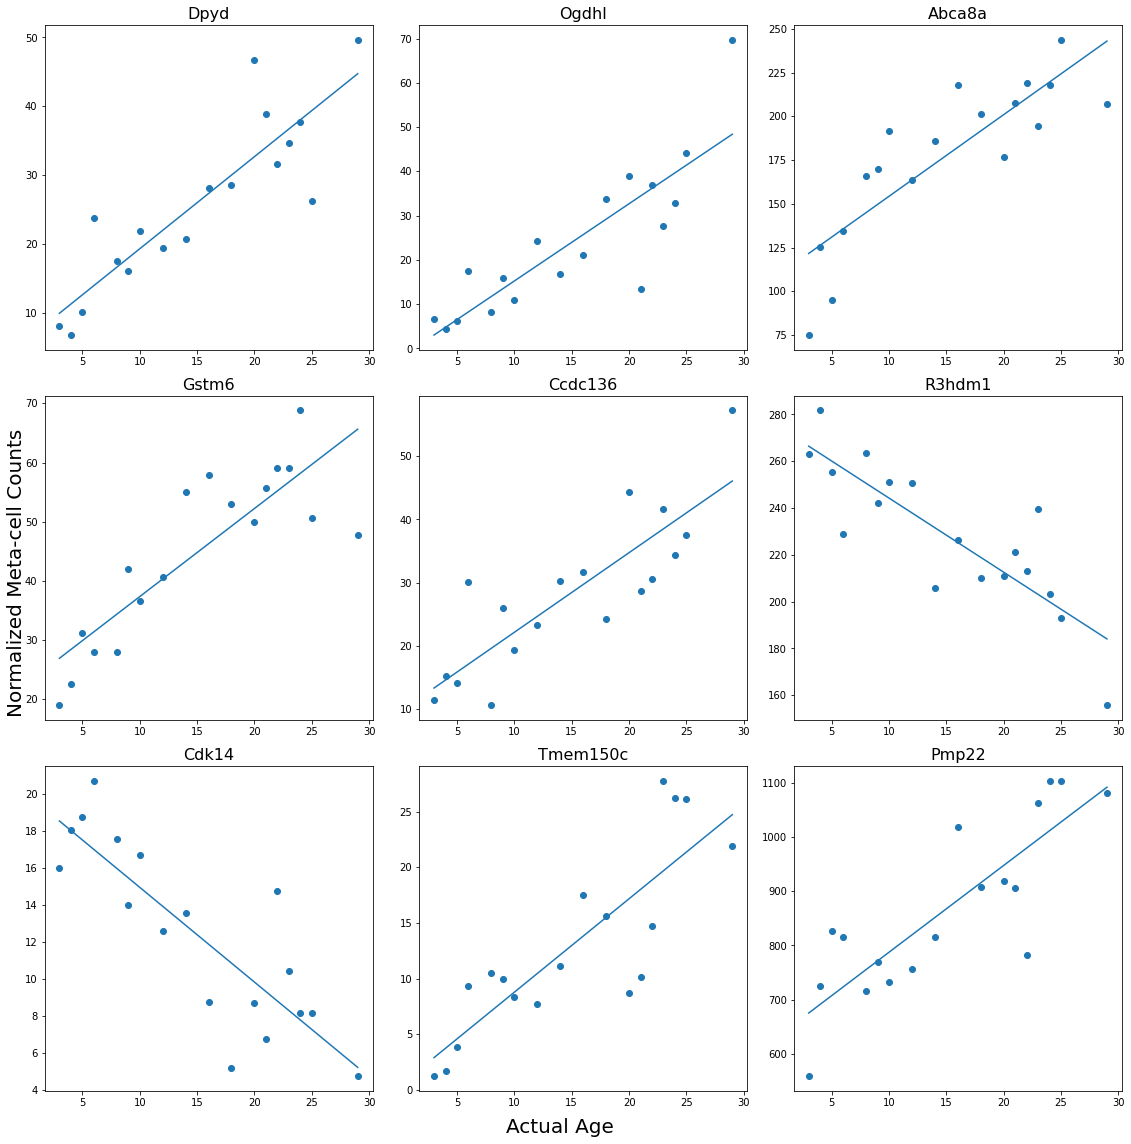

In [24]:
import seaborn as sns
figure, axes = plt.subplots(3, 3, figsize = (16,16))
axes = axes.ravel()
genes = top100[:9]
for i in tqdm(range(len(list(genes)))):
    data = []
    for age in age_groups:
        data.append(list(test[age].loc[[genes[i]]])[0])
    axes[i].scatter(age_groups, data)
    z = np.polyfit(age_groups, data, 1)
    p = np.poly1d(z)
    axes[i].plot(age_groups, p(age_groups))
    axes[i].set_title(genes[i], fontsize=16)
figure.supylabel("Normalized Meta-cell Counts", fontsize=20)
figure.supxlabel("Actual Age", fontsize=20)
figure.tight_layout()
plt.show()

In [25]:
df = pd.DataFrame(metaCells[1]).T
df.columns = age_groups

100%|██████████| 9/9 [00:00<00:00, 107.85it/s]


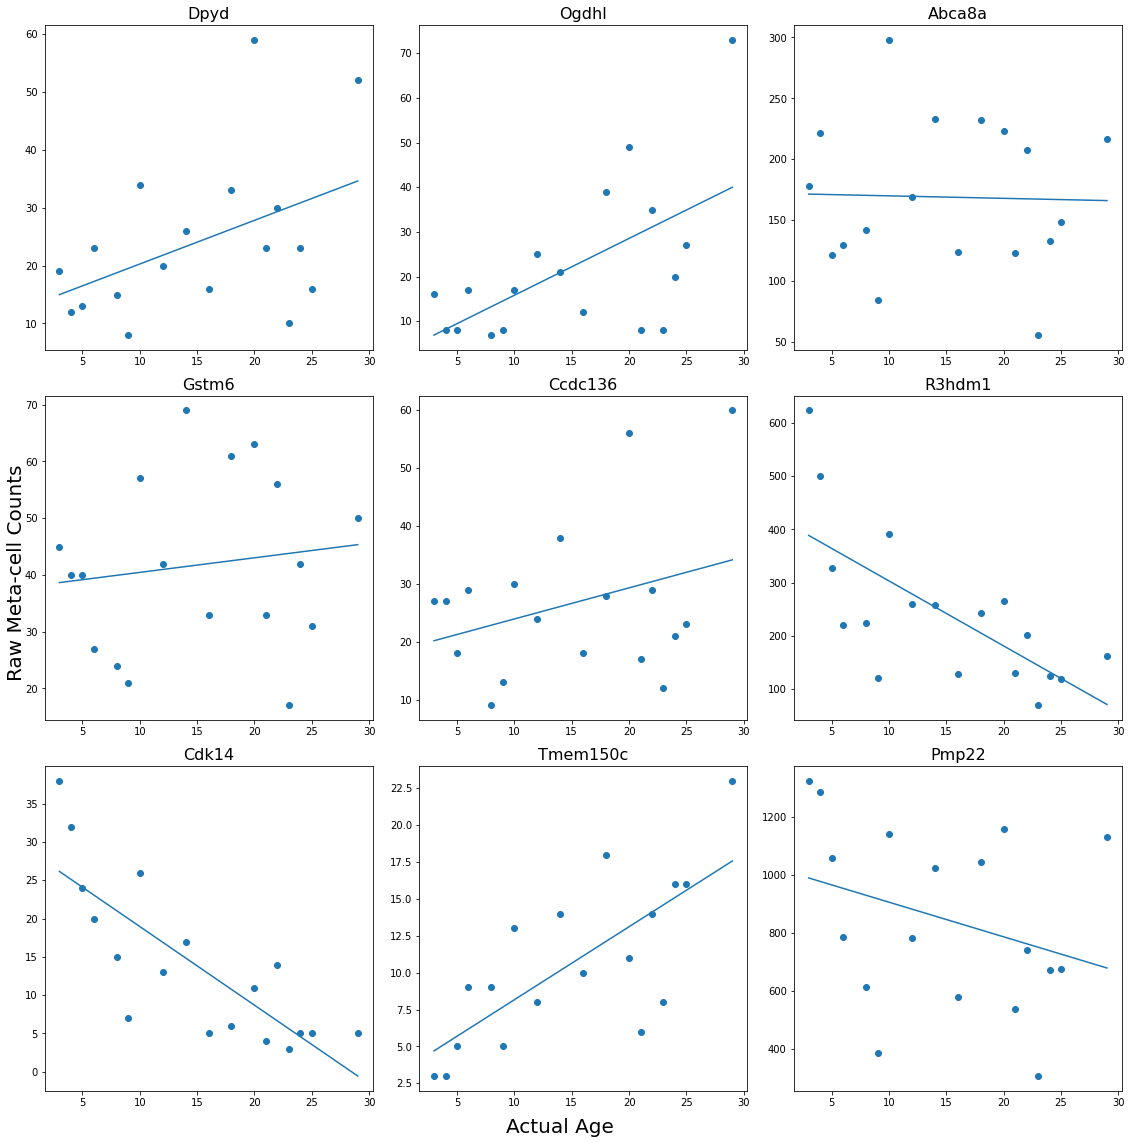

In [26]:
from sklearn.metrics import r2_score
figure, axes = plt.subplots(3, 3, figsize = (16,16))
axes = axes.ravel()
genes = top100[:9]
for i in tqdm(range(len(list(genes)))):
    data = []
    for age in age_groups:
        data.append(list(df[age].loc[[genes[i]]])[0])
    axes[i].scatter(age_groups, data)
    z = np.polyfit(age_groups, data, 1)
    p = np.poly1d(z)
    axes[i].plot(age_groups, p(age_groups))
    axes[i].set_title(genes[i], fontsize=16)
figure.supylabel("Raw Meta-cell Counts", fontsize=20)
figure.supxlabel("Actual Age", fontsize=20)
figure.tight_layout()
plt.show()

## Use top 100 abs correlated genes

## Compute frequencies for each gene at specific age group

### fraction of gene count itself for specific age
count_gene for that age/ total_count of genes of the whole matrix

### celltype 6 does not have age group 23

In [41]:
train_ages = {}
pred_freq_matrices = {}
for celltype in metaCells:
    df = pd.DataFrame(metaCells[celltype])[correlated_genes[celltype][:100]]
    df.index = age_groups
    frequency_matrix = df.div(np.sum(df, axis = 1), axis = 0)
    frequency_matrix = frequency_matrix.fillna(0)
    pred_freqs = np.zeros((frequency_matrix.shape))
    pred_freqs = pd.DataFrame(pred_freqs, columns=frequency_matrix.columns)
    train_age = np.array(frequency_matrix.index).reshape(-1,1)
    for gene in frequency_matrix:
        reg = LinearRegression(n_jobs=1).fit(train_age, np.array(frequency_matrix[gene]))
        predictions = reg.predict(train_age)
        pred_freqs[gene] = predictions
    pred_freqs[pred_freqs < 0] = 1e-6
    pred_freqs = pred_freqs.T
    pred_freqs.columns = frequency_matrix.index
    pred_freqs.to_csv("./Frequency_matrix/" + str(celltype) + "_subtype_fraction.csv")
    pred_freq_matrices[celltype] = pred_freqs
    train_ages[celltype] = train_age

In [42]:
pred_freq_matrices[6]

,3,4,5,6,8,9,10,12,14,16,18,20,21,22,23,24,25,29
Rilpl1,0.012758,0.012381,0.012004,0.011627,0.010873,0.010496,0.010120,0.009366,0.008612,0.007859,0.007105,0.006351,0.005974,0.005597,0.005221,0.004844,0.004467,0.002959
Fmc1,0.027339,0.027135,0.026930,0.026726,0.026318,0.026113,0.025909,0.025501,0.025092,0.024684,0.024275,0.023867,0.023662,0.023458,0.023254,0.023050,0.022845,0.022029
Wars,0.004345,0.004184,0.004023,0.003862,0.003539,0.003378,0.003217,0.002894,0.002572,0.002249,0.001927,0.001604,0.001443,0.001282,0.001121,0.000959,0.000798,0.000153
Gpatch1,0.005178,0.004960,0.004742,0.004523,0.004087,0.003868,0.003650,0.003213,0.002776,0.002340,0.001903,0.001466,0.001248,0.001030,0.000811,0.000593,0.000374,0.000001
Sipa1l1,0.004740,0.004574,0.004409,0.004244,0.003914,0.003748,0.003583,0.003253,0.002922,0.002592,0.002261,0.001931,0.001766,0.001600,0.001435,0.001270,0.001105,0.000444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Nvl,0.006409,0.006205,0.006000,0.005796,0.005388,0.005184,0.004980,0.004572,0.004164,0.003756,0.003348,0.002940,0.002736,0.002531,0.002327,0.002123,0.001919,0.001103
Top1,0.041076,0.041463,0.041850,0.042237,0.043012,0.043399,0.043786,0.044561,0.045335,0.046109,0.046884,0.047658,0.048046,0.048433,0.048820,0.049207,0.049594,0.051143
Phospho2,0.004709,0.004633,0.004557,0.004481,0.004330,0.004254,0.004178,0.004027,0.003875,0.003723,0.003572,0.003420,0.003345,0.003269,0.003193,0.003117,0.003041,0.002738
Dpy19l3,0.001261,0.001197,0.001133,0.001070,0.000942,0.000879,0.000815,0.000687,0.000560,0.000432,0.000305,0.000177,0.000114,0.000050,0.000001,0.000001,0.000001,0.000001


In [31]:
# df = pd.DataFrame(metaCells[1])
# df.index = age_groups
# df = df[top100]
# df

In [32]:
# np.sum(df, axis = 1)

In [33]:
# frequency_matrix = df.div(np.sum(df, axis = 1), axis = 0)
# frequency_matrix

## linear model for each gene among all the age groups

In [34]:
# pred_freqs = np.zeros((frequency_matrix.shape))
# pred_freqs = pd.DataFrame(pred_freqs, columns=frequency_matrix.columns)
# train_ages = np.array(frequency_matrix.index).reshape(-1,1)
# for gene in frequency_matrix:
#     reg = LinearRegression(n_jobs=1).fit(train_ages, np.array(frequency_matrix[gene]))
#     predictions = reg.predict(train_ages)
#     pred_freqs[gene] = predictions

In [35]:
# pred_freqs.index = age_groups

## Trying Possion Probability
r: Expected frequency from the linear model
k: counts of this specific gene
t: sum of the counts across all genes for that cell

In [36]:
# r: Expected frequency from the linear model
# k: counts of this specific gene
# t: sum of the counts across all genes for that cell
## only iterate the top 100 genes

## Testing the Poisson with a individual sample

In [51]:
from scipy.stats import poisson
import math

In [52]:
# pred_freqs[pred_freqs < 0] = 1e-6
# pred_freqs = pred_freqs.T
# pred_freqs.columns = df.index

In [53]:
# pred_freqs

In [54]:
# cell_sums = np.sum(df, axis = 1)
# cell_sums

In [55]:
pd.DataFrame(metaCells[6])[correlated_genes[6][:100]]

,Rilpl1,Fmc1,Wars,Gpatch1,Sipa1l1,Itga6,Ecsit,Fgl2,Cops6,Zfp326,...,Spata5,Ppdpf,Abracl,Gm26782,Rnf24,Nvl,Top1,Phospho2,Dpy19l3,Gon7
0,18.0,39.0,5.0,4.0,7.0,1.0,13.0,13.0,37.0,19.0,...,4.0,35.0,25.0,12.0,5.0,10.0,58.0,9.0,1.0,5.0
1,6.0,12.0,1.0,3.0,2.0,2.0,4.0,2.0,13.0,7.0,...,1.0,17.0,12.0,5.0,1.0,1.0,18.0,3.0,1.0,0.0
2,9.0,26.0,5.0,4.0,3.0,3.0,5.0,5.0,22.0,15.0,...,2.0,27.0,21.0,5.0,2.0,5.0,34.0,5.0,1.0,3.0
3,3.0,8.0,1.0,2.0,1.0,1.0,2.0,4.0,9.0,5.0,...,1.0,8.0,4.0,3.0,1.0,1.0,14.0,1.0,0.0,1.0
4,9.0,16.0,3.0,2.0,3.0,1.0,3.0,3.0,16.0,9.0,...,2.0,23.0,7.0,3.0,1.0,5.0,27.0,1.0,1.0,1.0
5,18.0,45.0,6.0,6.0,6.0,5.0,7.0,13.0,36.0,24.0,...,2.0,42.0,45.0,6.0,0.0,11.0,70.0,8.0,2.0,7.0
6,5.0,8.0,1.0,1.0,1.0,1.0,3.0,4.0,11.0,8.0,...,1.0,12.0,14.0,1.0,3.0,3.0,21.0,1.0,1.0,1.0
7,7.0,23.0,2.0,2.0,3.0,1.0,7.0,2.0,14.0,13.0,...,1.0,27.0,16.0,2.0,3.0,4.0,34.0,4.0,0.0,3.0
8,10.0,28.0,4.0,6.0,2.0,0.0,4.0,1.0,20.0,12.0,...,6.0,32.0,18.0,4.0,1.0,4.0,54.0,3.0,0.0,3.0
9,1.0,9.0,1.0,1.0,2.0,0.0,1.0,2.0,5.0,7.0,...,0.0,7.0,5.0,2.0,0.0,0.0,13.0,1.0,0.0,1.0


In [56]:

for age in pred_freqs:
    cell_group = oligodendro[oli_age_dict[age]]
    for cell in cell_group:
        _lambda = pred_freqs * oli_cell_sums[cell] # frequency of that gene expression * counts of all genes in that cell
        prob = poisson.pmf(np.array(cell_group[cell]).reshape(-1,1), _lambda)
        max_value = np.log(prob)
        max_value[max_value == -inf] = 0
        temp = np.sum(max_value, axis = 0).reshape(1,-1)
#         print("sum of loglikelihood: ")
#         display(pd.DataFrame(temp, columns = age_groups))
#         print(np.argmax(np.sum(np.log(prob), axis = 0)))
        max_value = train_ages[np.argmax(np.sum(max_value, axis = 0))]
        freq_probs[age].append(np.sum(np.log(prob), axis = 0))
        outcome[age].append(max_value[0])

NameError: name 'oligodendro' is not defined

In [57]:
from collections import defaultdict
def get_cells_byAge(cell_group):
    cell_group_ages = ages_df.T[cell_group.index]
    cell_group_age_dict = defaultdict(list)
    for cell in cell_group_ages:
        cell_group_age_dict[cell_group_ages[cell].values[0]].append(cell)
    return cell_group_age_dict

In [58]:
def get_singleCell_sums(cells):
    cell_sums = np.sum(cells, axis = 0)
    return(cell_sums)

In [59]:
from numpy import inf
def run_poisson(celltype, pred_freqs, raw_cells, train_ages):
    outcome = defaultdict(list)
    freq_probs = defaultdict(list)
    for age in pred_freqs:
        cell_group_byAge = get_cells_byAge(raw_cells)
        cell_group = raw_cells.T[cell_group_byAge[age]]
        cell_sums = get_singleCell_sums(cell_group)
        for cell in cell_group:
            _lambda = pred_freqs * cell_sums[cell] # frequency of that gene expression * counts of all genes in that cell
            prob = poisson.pmf(np.array(cell_group[cell]).reshape(-1,1), _lambda)
            max_value = np.log(prob)
            max_value[max_value == -inf] = 0
            temp = np.sum(max_value, axis = 0).reshape(1,-1)
            #print("sum of loglikelihood: ")
            #display(pd.DataFrame(temp, columns = age_groups))
            #print(np.argmax(np.sum(np.log(prob), axis = 0)))
            max_value = train_ages[np.argmax(np.sum(max_value, axis = 0))]
            freq_probs[age].append(np.sum(np.log(prob), axis = 0))
            outcome[age].append(max_value[0])
    pred_results[celltype] = outcome
    likelihood[celltype] = freq_probs
        #print("predicted_result: ", max_value[0], " true_value: ", cell)

In [60]:
pred_results = {}
likelihood = {}
for celltype in pred_freq_matrices:
    print(celltype)
    run_poisson(celltype, pred_freq_matrices[celltype], pd.DataFrame(raw_count[celltype_dict[celltype]]).T[correlated_genes[celltype][:100]], train_ages[celltype])

1
5
0


/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: divide by zero encountered in log
  if sys.path[0] == '':
/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in log


8
3
4
6
10
2
7
9


In [265]:
from matplotlib.pyplot import figure
def plot_violin(x, y, name):
    figure(figsize=(10, 4), dpi=80)
    ax = sns.violinplot(x, [int(inner) for outer in y for inner in outer])
    plt.ylabel("Predicted Age")
    plt.xlabel("True Age")
    plt.title(name)
    # adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
    plt.show()

In [272]:
names = []

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


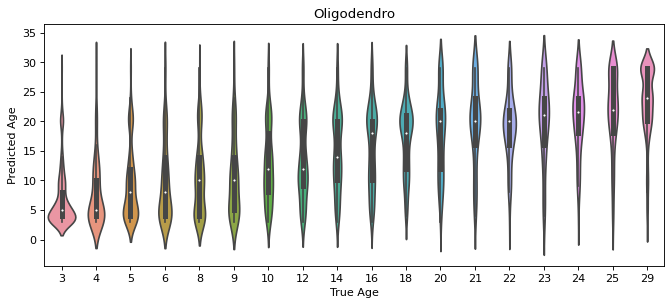

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


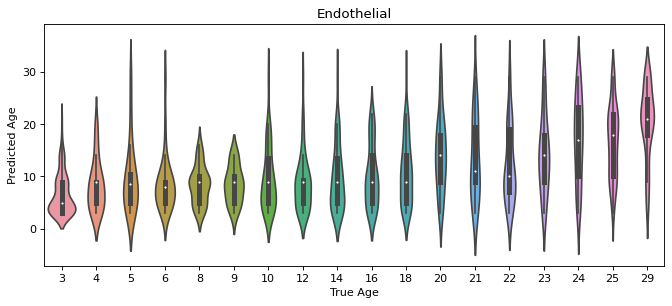

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


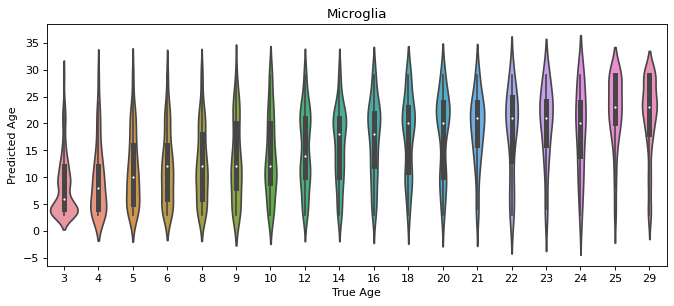

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


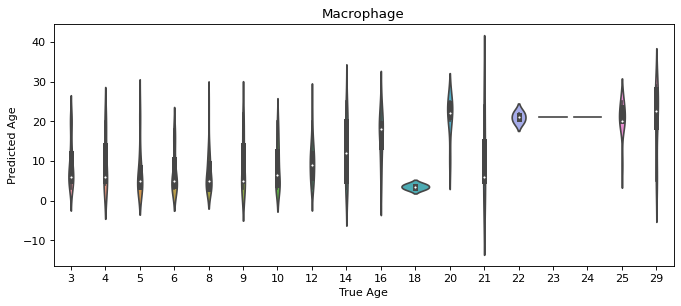

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


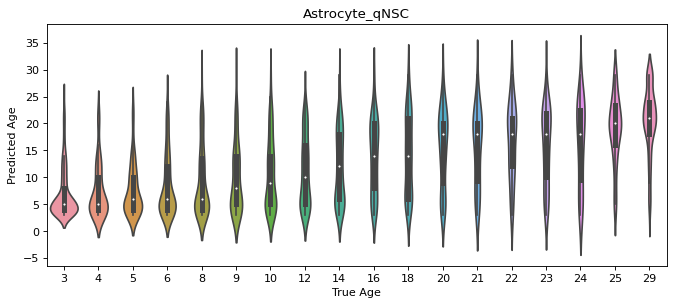

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


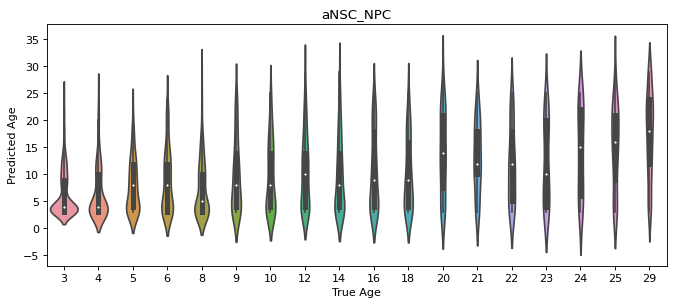

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


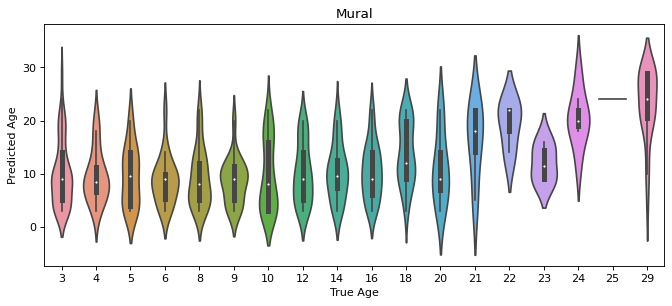

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


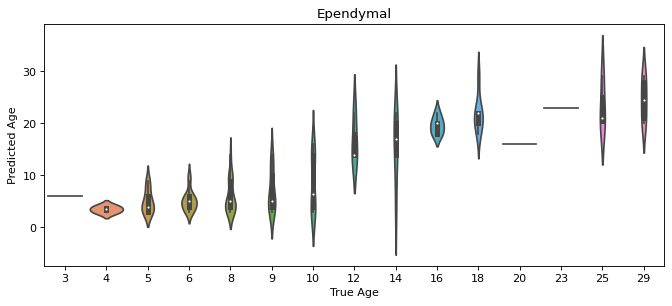

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


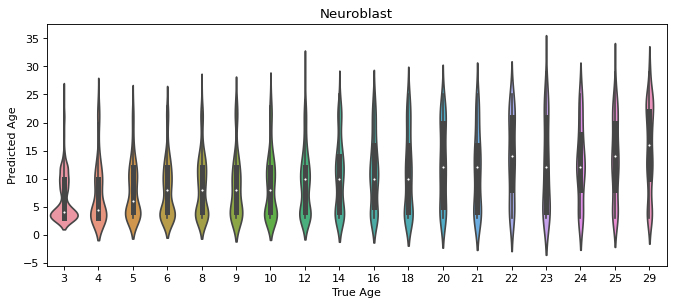

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


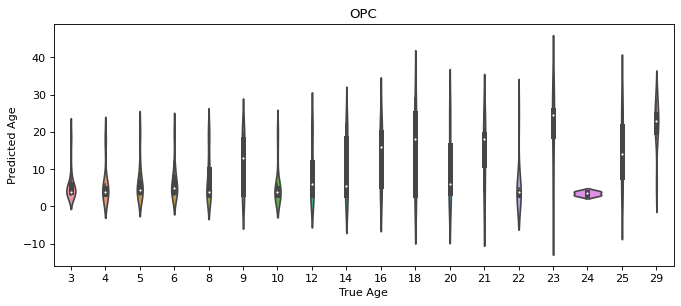

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


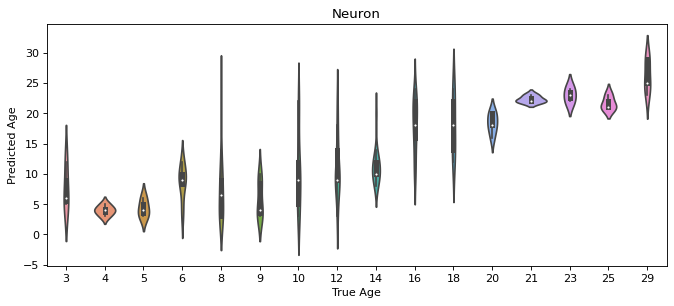

In [273]:
for cell in pred_results:
    outcome = pred_results[cell]
    x = [int(inner) for outer in list(outcome.values()) for inner in outer]
    y = []
    for key in list(outcome.keys()):
        y.append(len(outcome[key]) * [key])
    name = np.unique(celltype_names[celltype_dict[cell]])[0]
    names.append(name)
    plot_violin(x,y, name)

In [279]:
correlated = pd.DataFrame.from_dict(correlated_genes)
correlated.columns = names

In [282]:
correlated = correlated[:100]
correlated

,Oligodendro,Endothelial,Microglia,Macrophage,Astrocyte_qNSC,aNSC_NPC,Mural,Ependymal,Neuroblast,OPC,Neuron
0,Dpyd,Zswim7,Crlf2,Nav1,C4b,Lin7a,Rilpl1,1810062G17Rik,Ccsap,Gm42372,Tsc22d1
1,Ogdhl,Wdfy2,Sdf4,Zfp160,Slc22a18,Zc3hav1,Fmc1,Smg7,Coprs,Zfp292,Arl5a
2,Abca8a,2810474O19Rik,AW112010,Eva1b,Tspan13,Cebpa,Wars,C230035I16Rik,Fggy,Itgav,Aldh2
3,Gstm6,Ppih,Plcl2,Rnf150,Ltbp4,Cyp20a1,Gpatch1,Urah,Fis1,Jcad,Zhx1
4,Ccdc136,Plaa,Camk2n1,Gamt,Cnr1,Ednrb,Sipa1l1,Cep126,Dmrta2,Brwd3,Mesd
...,...,...,...,...,...,...,...,...,...,...,...
95,Lmo7,Asxl3,Rprd1b,Nfya,Setbp1,Ifi27,Nvl,Rarres2,Sf1,Ahi1,Phax
96,Fmo5,Il16,Ly9,Chmp6,Ccdc102a,Tnfrsf17,Top1,Omg,Camk1d,Gpld1,Tor1a
97,Gm4221,Trem2,Ddx3y,Asb10,Pcyt1b,Pfdn6,Phospho2,Arfgef3,Hspa9,D17Wsu92e,Cpsf6
98,Sag,Ifi27l2a,Elmo1,Ak3,Gbp2,Rwdd1,Dpy19l3,Elmod3,Gas2l3,Skp2,Ascc3


In [283]:
correlated.to_csv("metacells/correlated_genes_by_celltype.csv")

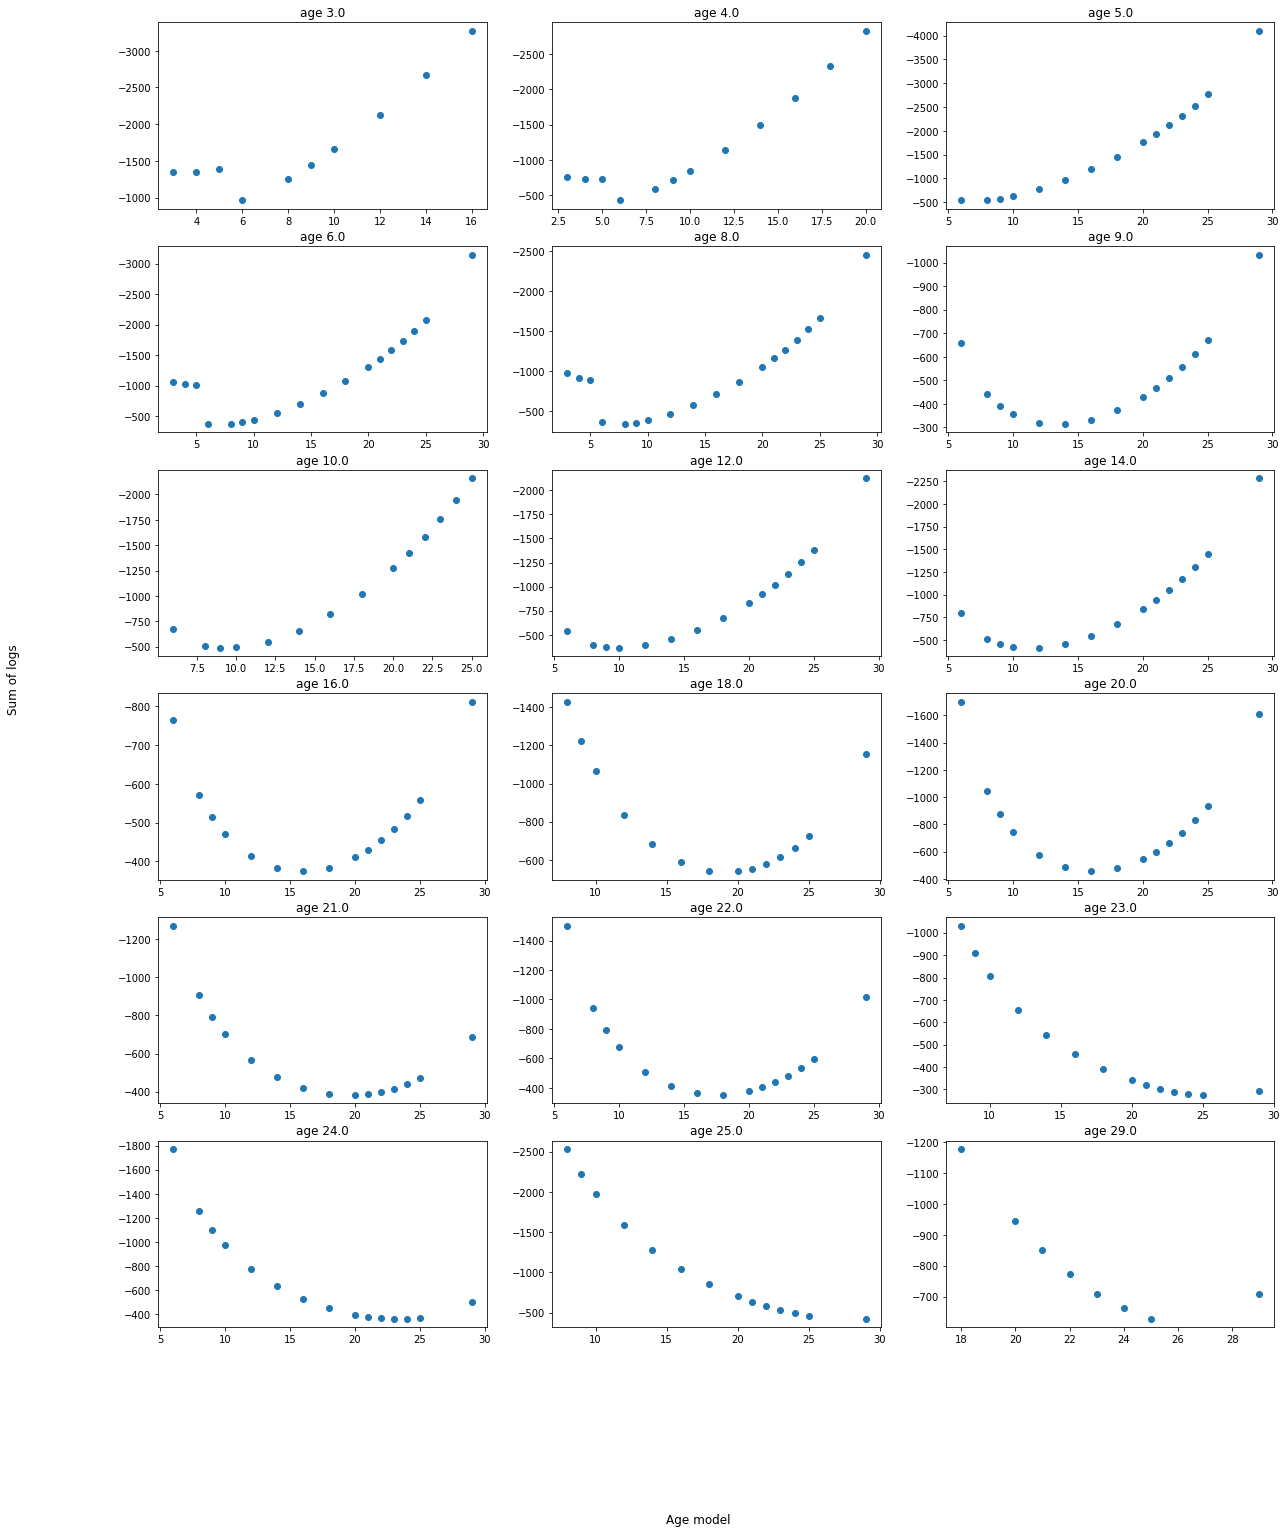

In [548]:
figure, axes = plt.subplots(6, 3, figsize = (20,24))
axes = axes.ravel()
cells = list(pred_freqs.columns)
for i in range(len(cells)):
    axes[i].scatter(list(age_groups), freq_probs[i])
    axes[i].set_title("age " + str(cells[i]))
    axes[i].invert_yaxis()
figure.supylabel("Sum of logs")
figure.supxlabel("Age model")
plt.show()
figure.savefig('metatcell_loglikelihood.png')

In [552]:
test["true"]

0      3.0
1      4.0
2      5.0
3      6.0
4      8.0
5      9.0
6     10.0
7     12.0
8     14.0
9     16.0
10    18.0
11    20.0
12    21.0
13    22.0
14    23.0
15    24.0
16    25.0
17    29.0
Name: true, dtype: float64

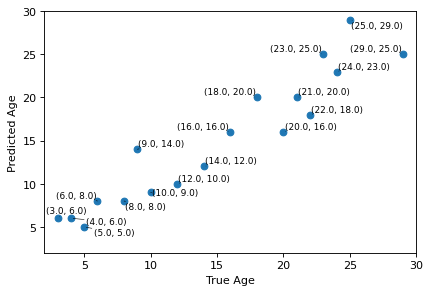

In [577]:
from matplotlib.pyplot import figure
from adjustText import adjust_text
figure(figsize=(6, 4), dpi=80)
x,y = test["true"], test["predicted"]
plt.scatter(test["true"], np.array(test["predicted"]))
labels = zip(x,y)
texts = []
for x, y, s in zip(test["true"], test["predicted"], labels):
    texts.append(plt.text(x, y, s, fontsize=8))
plt.ylabel("Predicted Age")
plt.xlim(2,30)
plt.ylim(2,30)
plt.xlabel("True Age")
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
plt.show()

In [505]:
# from scipy.stats import nbinom
# # number of success n: 
# # probability of single success: frequency of that gene expression
# from numpy import inf
# outcome = []
# freq_probs = []
# for cell in pred_freqs:
#     cell_sum = cell_sums[cell]
#     n = pred_freqs * cell_sum # frequency of that gene expression * counts of all genes in that cell
#     prob = poisson.pmf(np.array(df.T[cell]).reshape(-1,1), _lambda)
#     max_value = np.log(prob)
#     max_value[max_value == -inf] = 0
#     print(np.sum(max_value, axis = 0))
# #    print(np.argmax(np.sum(np.log(prob), axis = 0)))
#     max_value = train_ages[np.argmax(np.sum(max_value, axis = 0))]
#     freq_probs.append(np.sum(np.log(prob), axis = 1))
#     outcome.append(max_value[0])
#     print(max_value[0])

In [506]:
test = pd.DataFrame(zip(outcome, list(df.index)), columns=["predicted", "true"])

In [507]:
test

,predicted,true
0,6.0,3.0
1,6.0,4.0
2,5.0,5.0
3,8.0,6.0
4,8.0,8.0
5,14.0,9.0
6,9.0,10.0
7,10.0,12.0
8,12.0,14.0
9,16.0,16.0


In [508]:
test[test["predicted"] == test["true"]].shape[0] / test.shape[0]

0.16666666666666666

## next step: sum the likelihood for each age for a single cell

In [619]:
oligodendro = raw_count[celltype_dict[1]].T[top100]

In [620]:
oligodendro

,Dpyd,Ogdhl,Abca8a,Gstm6,Ccdc136,R3hdm1,Cdk14,Tmem150c,Pmp22,Acot11,...,Eif4e,Gm49375,2900011O08Rik,B3gnt2,Pes1,Lmo7,Fmo5,Gm4221,Sag,Pcdhb18
AAACCCAAGAGTCTTC_1,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCAGTCACTCTC_1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCATCCTGCTAC_1,0,0,0,1,0,1,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCATCTTAGCAG_1,0,0,0,0,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0
AAACGAACAGCAGTTT_1,1,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGATCACTTCATT-1_4,0,0,0,2,0,0,0,0,7,0,...,0,0,0,0,0,0,0,0,0,0
TTTGACTCACAGTCCG-1_4,0,0,0,0,0,2,0,0,1,0,...,1,0,0,0,1,0,0,0,0,0
TTTGGAGAGCCGTTGC-1_4,0,0,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,0,0,0
TTTGGAGGTAGAGGAA-1_4,0,1,1,0,0,1,0,0,6,0,...,1,0,0,0,0,0,0,0,0,1


In [621]:
oli_cell_sums = np.sum(oligodendro, axis = 1)
oli_cell_sums = oli_cell_sums.T
oli_cell_sums

AAACCCAAGAGTCTTC_1      21
AAACCCAGTCACTCTC_1      33
AAACCCATCCTGCTAC_1      43
AAACCCATCTTAGCAG_1      58
AAACGAACAGCAGTTT_1      36
                        ..
TTTCGATCACTTCATT-1_4    95
TTTGACTCACAGTCCG-1_4    35
TTTGGAGAGCCGTTGC-1_4    74
TTTGGAGGTAGAGGAA-1_4    48
TTTGGTTTCTTTACAC-1_4    62
Length: 5943, dtype: int64

In [612]:
from collections import defaultdict
oligodendro_ages = ages_df.T[oligodendro.index]
oli_age_dict = defaultdict(list)
for cell in oligodendro_ages:
    oli_age_dict[oligodendro_ages[cell].values[0]].append(cell)
oli_age_dict    

defaultdict(list,
            {29.0: ['AAACCCAAGAGTCTTC_1',
              'AAAGGATCATCGTGCG_1',
              'AAAGTCCAGTTGGAAT_1',
              'AAAGTCCTCCTCTAAT_1',
              'AACAACCCAACCACAT_1',
              'AACAACCTCTAGTACG_1',
              'AACCACACAAACTGCT_1',
              'AACCATGTCGAGATGG_1',
              'AACCTGAAGTAGTCTC_1',
              'AACCTGACATTCTGTT_1',
              'AACGAAATCTAAGCGT_1',
              'AAGATAGCAGAACGCA_1',
              'AAGATAGTCTCTGCTG_1',
              'AAGCGAGAGCACAAAT_1',
              'AAGCGTTTCGCCAGAC_1',
              'AAGCGTTTCGGATACT_1',
              'AAGGAATTCACCCTTG_1',
              'AAGGTAAGTCAAGTTC_1',
              'AAGTCGTGTCTTTCAT_1',
              'AAGTCGTGTTTGACAC_1',
              'AAGTTCGCATGGAAGC_1',
              'AAGTTCGGTGCACGCT_1',
              'AATCACGTCATTTGCT_1',
              'AATCACGTCTAACACG_1',
              'AATCGACAGATACAGT_1',
              'AATGCCAAGACTGAGC_1',
              'AATGCCACACGCTATA_1',
    

In [623]:
oligodendro = oligodendro.T

In [626]:
pred_freqs

,3.0,4.0,5.0,6.0,8.0,9.0,10.0,12.0,14.0,16.0,18.0,20.0,21.0,22.0,23.0,24.0,25.0,29.0
Dpyd,0.000664,0.000726,0.000788,0.000850,0.000973,0.001035,0.001097,0.001220,0.001344,0.001467,0.001590,0.001714,0.001776,0.001837,0.001899,0.001961,0.002023,0.002270
Ogdhl,0.000287,0.000370,0.000453,0.000536,0.000701,0.000784,0.000867,0.001032,0.001198,0.001364,0.001529,0.001695,0.001778,0.001861,0.001944,0.002026,0.002109,0.002441
Abca8a,0.007595,0.007774,0.007952,0.008131,0.008488,0.008666,0.008845,0.009202,0.009559,0.009916,0.010273,0.010630,0.010809,0.010988,0.011166,0.011345,0.011523,0.012237
Gstm6,0.001698,0.001761,0.001824,0.001886,0.002012,0.002074,0.002137,0.002262,0.002388,0.002513,0.002639,0.002764,0.002827,0.002890,0.002952,0.003015,0.003078,0.003328
Ccdc136,0.000880,0.000935,0.000990,0.001045,0.001155,0.001210,0.001265,0.001375,0.001485,0.001595,0.001705,0.001815,0.001870,0.001925,0.001980,0.002035,0.002090,0.002310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Lmo7,0.000176,0.000168,0.000160,0.000153,0.000138,0.000130,0.000122,0.000107,0.000092,0.000077,0.000062,0.000046,0.000039,0.000031,0.000024,0.000016,0.000008,0.000001
Fmo5,0.000344,0.000359,0.000374,0.000389,0.000419,0.000435,0.000450,0.000480,0.000510,0.000541,0.000571,0.000601,0.000616,0.000632,0.000647,0.000662,0.000677,0.000738
Gm4221,0.001933,0.001859,0.001785,0.001711,0.001564,0.001490,0.001416,0.001269,0.001121,0.000973,0.000826,0.000678,0.000604,0.000531,0.000457,0.000383,0.000309,0.000014
Sag,0.000056,0.000066,0.000076,0.000087,0.000108,0.000118,0.000128,0.000149,0.000170,0.000191,0.000211,0.000232,0.000243,0.000253,0.000263,0.000274,0.000284,0.000326


In [627]:
oli_cell_sums[cell]

21

In [629]:
outcome = defaultdict(list)
freq_probs = defaultdict(list)
## loop over each age group in pred_freqs
for age in pred_freqs:
    cell_group = oligodendro[oli_age_dict[age]]
    for cell in cell_group:
        _lambda = pred_freqs * oli_cell_sums[cell] # frequency of that gene expression * counts of all genes in that cell
        prob = poisson.pmf(np.array(cell_group[cell]).reshape(-1,1), _lambda)
        max_value = np.log(prob)
        max_value[max_value == -inf] = 0
        temp = np.sum(max_value, axis = 0).reshape(1,-1)
#         print("sum of loglikelihood: ")
#         display(pd.DataFrame(temp, columns = age_groups))
#         print(np.argmax(np.sum(np.log(prob), axis = 0)))
        max_value = train_ages[np.argmax(np.sum(max_value, axis = 0))]
        freq_probs[age].append(np.sum(np.log(prob), axis = 0))
        outcome[age].append(max_value[0])
#         print("predicted_result: ", max_value[0], " true_value: ", cell)

In [676]:
x = [int(inner) for outer in list(outcome.values()) for inner in outer]
y = []
for key in list(outcome.keys()):
    y.append(len(outcome[key]) * [key])

In [677]:
len(x), len([inner for outer in y for inner in outer])

(5943, 5943)

/Users/charlotte/opt/anaconda3/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


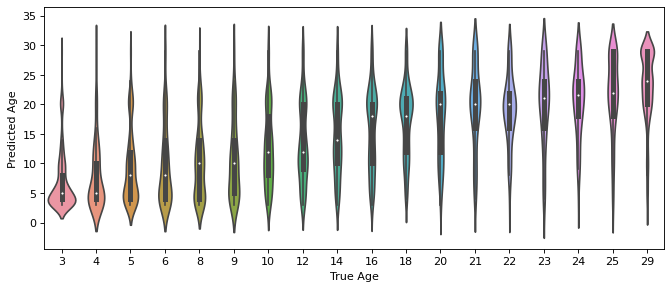

In [696]:
from matplotlib.pyplot import figure
from adjustText import adjust_text
figure(figsize=(10, 4), dpi=80)
ax = sns.violinplot(x, [int(inner) for outer in y for inner in outer])
plt.ylabel("Predicted Age")
# plt.xlim(2,30)
# plt.ylim(2,30)
plt.xlabel("True Age")
# adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
plt.show()

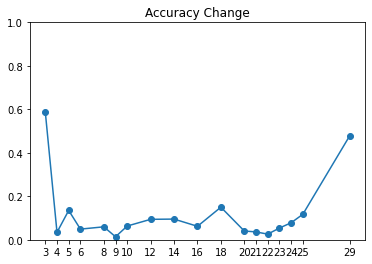

In [707]:
plt.plot(list(outcome.keys()), accuracy, marker="o")
plt.title("Accuracy Change")
plt.ylim(0.0,1.0)
plt.xticks(list(outcome.keys()))
plt.show()

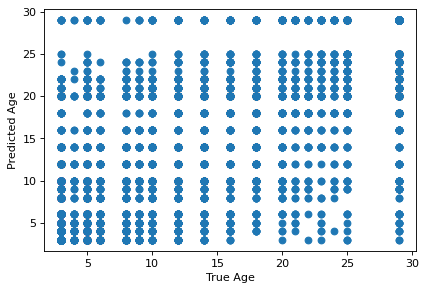

In [681]:
from matplotlib.pyplot import figure
from adjustText import adjust_text
figure(figsize=(6, 4), dpi=80)
plt.scatter(x, [int(inner) for outer in y for inner in outer])
# labels = zip(x,y)
# texts = []
# for x, y, s in zip(test["true"], test["predicted"], labels):
#     texts.append(plt.text(x, y, s, fontsize=8))
plt.ylabel("Predicted Age")
# plt.xlim(2,30)
# plt.ylim(2,30)
plt.xlabel("True Age")
# adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
plt.show()

In [685]:
accuracy = []
for key in outcome:
    accur = 0
    for value in outcome[key]:
        if value == key:
            accur += 1
    accuracy.append(accur / len(outcome[key]))

In [686]:
accuracy

[0.5878489326765188,
 0.03453947368421053,
 0.13505747126436782,
 0.049145299145299144,
 0.05964912280701754,
 0.013986013986013986,
 0.06333973128598848,
 0.09418282548476455,
 0.09523809523809523,
 0.062111801242236024,
 0.15,
 0.04044117647058824,
 0.03626943005181347,
 0.026022304832713755,
 0.05405405405405406,
 0.0783132530120482,
 0.11724137931034483,
 0.4778761061946903]